# Low Carbon Index Tracking Portfolio — CalPERS Case Study
### Ecole des Mines Paris Tech · Mastère OSE 2025-2026 · Climate Change Finance

**Objective:** Build a low-carbon version of the S&P500 for CalPERS that simultaneously:
1. Reduces carbon footprint/intensity by **≥ 50%** vs the S&P500 benchmark  
2. Controls tracking error at **3–5%**  
3. Preserves or improves the **Sharpe ratio**

**Method:** Positive screening (50 stocks) + 6 portfolio optimization strategies, out-of-sample backtest (1991–2019), 2-year rolling window, quarterly rebalancing.


## 0. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#FAFAFA',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

COLORS = {
    'Max ENC (Dollar)'   : '#2196F3',
    'Max ENC (Risk)'     : '#4CAF50',
    'Min Variance'       : '#FF9800',
    'Max Diversification': '#9C27B0',
    'Max Decorrelation'  : '#F44336',
    'Min Tracking Error' : '#00BCD4',
    'S&P500'             : '#37474F',
}

DATA_PATH = 'case study - Individual_stock_data.xlsx'

## 1. Data Loading

Three sheets from the Excel file:
- **stock prices** — weekly prices for 505 S&P500 constituents (1989–2019)
- **carbon footprint data** — Scope 1 & 2 emissions, market cap, revenues per stock
- **SP500** — S&P500 Total Return Index (benchmark)


In [3]:
df_prices_raw = pd.read_excel(DATA_PATH, sheet_name='stock prices',
                               index_col=0, parse_dates=True)
df_carbon_raw = pd.read_excel(DATA_PATH, sheet_name='carbon footprint data',
                               index_col=0)
df_sp500_raw  = pd.read_excel(DATA_PATH, sheet_name='SP500',
                               index_col=0, parse_dates=True)

# Convert prices to numeric (some cells contain 'NA' strings)
df_prices = df_prices_raw.apply(pd.to_numeric, errors='coerce')
df_sp500  = pd.to_numeric(df_sp500_raw.iloc[:, 0])

# Compute carbon metrics from raw Scope 1 & 2 columns
# (Excel formula columns are read as strings — we recompute them)
df_c = df_carbon_raw.copy()
df_c['SCOPE1']       = pd.to_numeric(df_c['SCOPE1'], errors='coerce')
df_c['SCOPE2']       = pd.to_numeric(df_c['SCOPE2'], errors='coerce')
df_c['EMISSIONS']    = df_c['SCOPE1'] + df_c['SCOPE2']
df_c['MARKET_VALUE'] = pd.to_numeric(df_c['MARKET_VALUE'], errors='coerce')
df_c['REVENUES']     = pd.to_numeric(df_c['REVENUES'],     errors='coerce')

# Carbon Footprint = Emissions / Market Cap  (tCO2 per $M invested)
# in excel values are in Millions of $ and ktCO2
df_c['FOOTPRINT'] = df_c['EMISSIONS'] / df_c['MARKET_VALUE'] * 1000
# Carbon Intensity = Emissions / Revenues   (tCO2 per $M revenue)
df_c['INTENSITY'] = df_c['EMISSIONS'] / df_c['REVENUES']    * 1000

print(f"Prices     : {df_prices.shape[0]:,} weeks × {df_prices.shape[1]} stocks")
print(f"Date range : {df_prices.index[0].date()} → {df_prices.index[-1].date()}")
print(f"Carbon data: {len(df_c)} stocks across {df_c['SECTOR_NAME'].nunique()} sectors")
print(f"SP500  : {len(df_sp500)}")


Prices     : 1,567 weeks × 505 stocks
Date range : 1989-12-05 → 2019-12-10
Carbon data: 505 stocks across 11 sectors
SP500  : 1567


## 2. S&P500 Carbon Baseline

We compute the cap-weighted carbon profile of the S&P500 as our reference.  
Both **carbon footprint** (tCO₂ / $M invested) and **carbon intensity** (tCO₂ / $M revenue) are computed.  
Our target is to reduce both by at least **50%**.


In [4]:
# Cap-weighted benchmark carbon metrics
total_mktcap        = df_c['MARKET_VALUE'].sum()
df_c['W_BENCH']     = df_c['MARKET_VALUE'] / total_mktcap

sp500_footprint = float((df_c['FOOTPRINT'] * df_c['W_BENCH']).sum())
sp500_intensity = float((df_c['INTENSITY'] * df_c['W_BENCH']).sum())
TARGET_FP       = sp500_footprint * 0.50
TARGET_INT      = sp500_intensity * 0.50

print("─" * 55)
print(f"  S&P500 Carbon Footprint  : {sp500_footprint:>8.2f}  tCO₂/$M invested")
print(f"  S&P500 Carbon Intensity  : {sp500_intensity:>8.2f}  tCO₂/$M revenue")
print("─" * 55)
print(f"  Target (−50%) Footprint  : {TARGET_FP:>8.2f}")
print(f"  Target (−50%) Intensity  : {TARGET_INT:>8.2f}")
print("─" * 55)


───────────────────────────────────────────────────────
  S&P500 Carbon Footprint  :    55.69  tCO₂/$M invested
  S&P500 Carbon Intensity  :   122.11  tCO₂/$M revenue
───────────────────────────────────────────────────────
  Target (−50%) Footprint  :    27.84
  Target (−50%) Intensity  :    61.06
───────────────────────────────────────────────────────


In [5]:
# Carbon profile by sector
sector_carbon = df_c.groupby('SECTOR_NAME').apply(lambda g: pd.Series({
    'N stocks'        : len(g),
    'Bench weight (%)': round(g['W_BENCH'].sum() * 100, 2),
    'Avg Footprint'   : round(g['FOOTPRINT'].mean(), 1),
    'Avg Intensity'   : round(g['INTENSITY'].mean(), 1),
})).sort_values('Avg Intensity', ascending=False)

display(sector_carbon)


,N stocks,Bench weight (%),Avg Footprint,Avg Intensity
SECTOR_NAME,,,,
Util,28.0,3.16,1297.1,2718.7
Materials,28.0,2.65,355.5,652.5
Energy,28.0,4.20,375.2,509.6
Industrial,69.0,9.20,209.0,215.6
Real Estate,32.0,2.82,19.7,126.5
Consumer Discretionary,64.0,10.18,56.1,70.8
Consumer Staples,33.0,7.97,66.9,66.9
IT,69.0,22.72,13.0,29.6
Communication Services,27.0,10.56,17.4,21.6


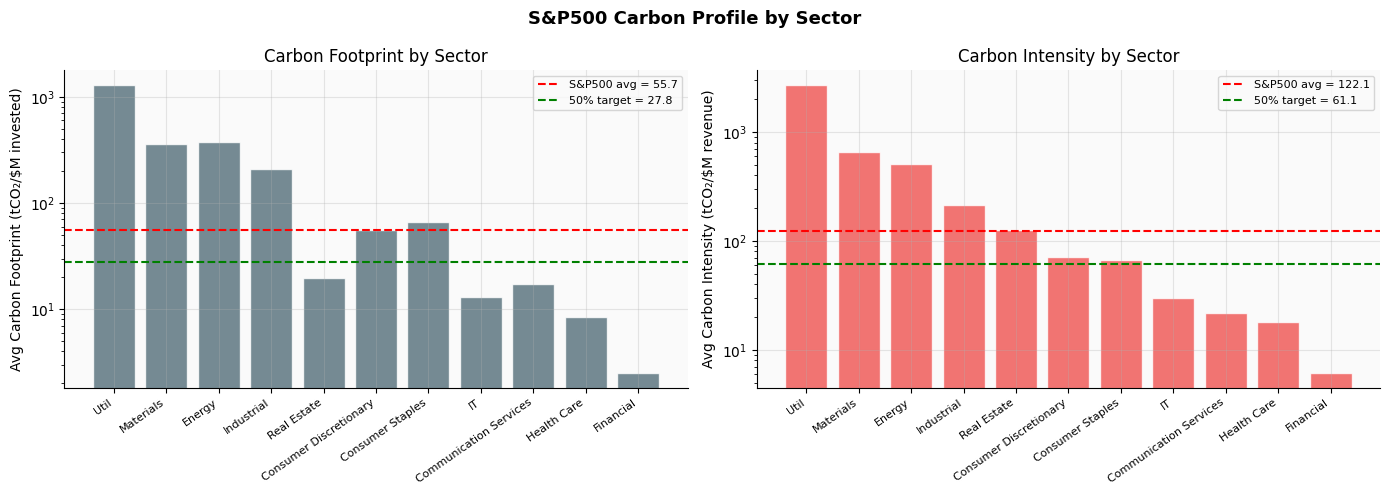

→ Utilities, Energy and Materials are the dominant carbon emitters


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('S&P500 Carbon Profile by Sector', fontsize=13, fontweight='bold')

sectors = sector_carbon.index
x = np.arange(len(sectors))

# Footprint
bars1 = ax1.bar(x, sector_carbon['Avg Footprint'], color='#546E7A', alpha=0.8, edgecolor='white')
ax1.axhline(sp500_footprint, color='red', ls='--', lw=1.5, label=f'S&P500 avg = {sp500_footprint:.1f}')
ax1.axhline(TARGET_FP, color='green', ls='--', lw=1.5, label=f'50% target = {TARGET_FP:.1f}')
ax1.set_xticks(x); ax1.set_xticklabels(sectors, rotation=35, ha='right', fontsize=8)
ax1.set_ylabel('Avg Carbon Footprint (tCO₂/$M invested)'); ax1.legend(fontsize=8)
ax1.set_yscale('log'); ax1.set_title('Carbon Footprint by Sector')

# Intensity
ax2.bar(x, sector_carbon['Avg Intensity'], color='#EF5350', alpha=0.8, edgecolor='white')
ax2.axhline(sp500_intensity, color='red', ls='--', lw=1.5, label=f'S&P500 avg = {sp500_intensity:.1f}')
ax2.axhline(TARGET_INT, color='green', ls='--', lw=1.5, label=f'50% target = {TARGET_INT:.1f}')
ax2.set_xticks(x); ax2.set_xticklabels(sectors, rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('Avg Carbon Intensity (tCO₂/$M revenue)'); ax2.legend(fontsize=8)
ax2.set_yscale('log'); ax2.set_title('Carbon Intensity by Sector')

plt.tight_layout()
plt.show()
print("→ Utilities, Energy and Materials are the dominant carbon emitters")


- prendre une pondération dans mon prtefeuille des 50 qui représente le meme pourcentage que celui de la représentation dans le SNP500, ca va permettre de probablement diminuer la tracking error
- mais en meme temps si on veut pas de biais sectoriel ce serait mieux de prendre le même nb pr chaque secteur, ptet qu'il y a un biais qui fait que les entreprises de certains secteurs sont moins représentées dans le S&P500, ou bien aussi ce st ptet des secterus qui ont besoin de moins d'entreprises, auquel cas il faut viser atteindre la même proportion de market cap au sein de chaque secteur (par exemple prendre l'ensemble des entreprises qui pour chaque secteru représentent 20% de al capitalisation du secteur, mais ic on est limité car on a pas les données de cap totaux de chaque secteur).
- cependant la carbon footprint a comme default qu'elle sous évalue l'impact carbone des entreprises à frote capitalisation, voir potentiellement surévaluées, 
- la carbone intensity montre réellement cb l'entreprise pollue pr faire de la valeur, mais elle souffre d'un fort biais sectoriel.
- Le choix le plus logique me semble être de s'intéresser à l'intensité carbone, car c'est une meilleure métrique pour vérifier l'efficacité de chaque entreprise à produire de la richesse, et pr répoondre au biais secto le mieux est pour moi de prendre la meme part que celle de chaque secteur dans le snp 500

encore mieux, je devrais prendre une representation de chaque secteru pas en poids de capitalisation ds le snp500 mais au nombre d'entreprise dans le s&p500, mais on va encore une fois plus devier je pense du S&P500 et avoir une frote tracking error, bon je vais tester comme vu plus haut dans un premier temps ( a tester ares et voir si on peut demonter mathématiquement qu'une solution est meilleure).

ok non, si je choisi les entreprises selon la ponderation dans le s&p500, je vais moins bien diversifier, il vaut mieux faire comme si on s'intéresser à un EW

## 3. Stock Selection — Positive Screening (50 stocks)

**Methodology:**
cf au dessus

potentiellement pas se limiter à 50, ou test 50 et 100

comment gérer les arrondis ?
regarder à partir de quelle date on s'intéresse au problème (en premier lieu pour avoir les meilleures entreprises de notre portefeuille)

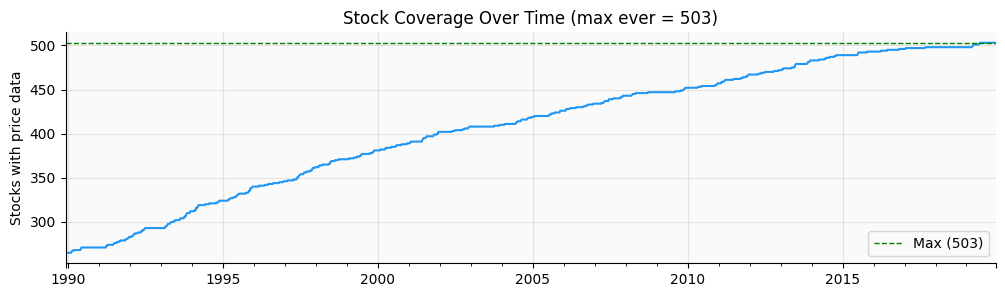

Threshold : 95% of max = 477 stocks
Start date: 2013-06-25

Universe at 2013-06-25: 313 stocks with carbon data
SECTOR_NAME
IT                        42
Financial                 42
Industrial                40
Health Care               39
Consumer Discretionary    34
Consumer Staples          30
Util                      21
Materials                 20
Real Estate               19
Energy                    14
Communication Services    12
Name: count, dtype: int64

Sector quotas (total = 49):
  IT                          :  7 stocks  (S&P500 weight: 13.4%)
  Financial                   :  7 stocks  (S&P500 weight: 13.4%)
  Industrial                  :  6 stocks  (S&P500 weight: 12.8%)
  Health Care                 :  6 stocks  (S&P500 weight: 12.5%)
  Consumer Discretionary      :  5 stocks  (S&P500 weight: 10.9%)
  Consumer Staples            :  5 stocks  (S&P500 weight: 9.6%)
  Util                        :  3 stocks  (S&P500 weight: 6.7%)
  Materials                   :  3 stocks 

In [7]:
N_SELECT = 50   # 

# ── Step 1: Find first date where coverage reaches a threshold ──
coverage_over_time = df_prices.notna().sum(axis=1)

plt.figure(figsize=(12, 3))
coverage_over_time.plot(color='#2196F3')
plt.ylabel('Stocks with price data')
plt.title('Stock Coverage Over Time (max ever = 503)')
plt.axhline(503, color='green', ls='--', lw=1, label='Max (503)')
plt.legend(); plt.show()

# Max coverage is 503 — pick a threshold (e.g. 95% = 478 stocks)
COVERAGE_THRESHOLD = 0.95
min_stocks = int(coverage_over_time.max() * COVERAGE_THRESHOLD)
start_date = coverage_over_time[coverage_over_time >= min_stocks].index[0]

print(f"Threshold : {COVERAGE_THRESHOLD:.0%} of max = {min_stocks} stocks")
print(f"Start date: {start_date.date()}")

# ── Step 2: Universe = stocks available at start_date WITH carbon data ──
available_at_start = df_prices.loc[start_date].dropna().index.tolist()
universe = [
    t for t in available_at_start
    if t in df_c.index
    and pd.notna(df_c.loc[t, 'INTENSITY'])
    and pd.notna(df_c.loc[t, 'MARKET_VALUE'])
]
df_u = df_c.loc[universe].copy()

print(f"\nUniverse at {start_date.date()}: {len(universe)} stocks with carbon data")
print(df_u['SECTOR_NAME'].value_counts())

# ── Step 3: Compute sector quotas = mirror S&P500 sector cap weights ──
# S&P500 sector weights = each sector's total market cap / total S&P500 market cap
# sp500_sector_weights = (
#     df_c.groupby('SECTOR_NAME')['MARKET_VALUE'].sum()
#     / df_c['MARKET_VALUE'].sum()
# )

#S&P500 sector proportions : each sector number of companies in the selected unvierse / total number of companies in the selected universe
sp500_sector_proportions = df_u['SECTOR_NAME'].value_counts() / len(df_u)

# Allocate N_SELECT stocks proportionally across sectors
raw_quotas = (sp500_sector_proportions * N_SELECT).round()
quotas = raw_quotas.astype(int)

# # Adjust rounding to hit exactly N_SELECT
# diff = N_SELECT - quotas.sum()
# # Add/remove from largest sectors first
# sorted_sectors = sp500_sector_proportions.sort_values(ascending=False).index
# i = 0
# while diff != 0:
#     s = sorted_sectors[i % len(sorted_sectors)]
#     max_avail = df_u[df_u['SECTOR_NAME'] == s].shape[0]
#     if diff > 0 and quotas[s] < max_avail:
#         quotas[s] += 1; diff -= 1
#     elif diff < 0 and quotas[s] > 1:
#         quotas[s] -= 1; diff += 1
#     i += 1
# or not if it is different than 50 maybe it is for the better

print(f"\nSector quotas (total = {quotas.sum()}):")
for s, q in quotas.sort_values(ascending=False).items():
    w = sp500_sector_proportions[s]
    print(f"  {s:<28}: {q:>2} stocks  (S&P500 weight: {w:.1%})")

# ── Step 4: Within each sector, pick lowest carbon intensity ──
selected_tickers = []
for sector, n_pick in quotas.items():
    if n_pick == 0:
        continue
    sector_stocks = df_u[df_u['SECTOR_NAME'] == sector]
    if len(sector_stocks) == 0:
        print(f"  WARNING: no stocks available for {sector}")
        continue
    picked = (sector_stocks
              .sort_values('INTENSITY', ascending=True)
              .head(n_pick)
              .index.tolist())
    selected_tickers.extend(picked)

df_sel = df_c.loc[selected_tickers].copy()

# ── Step 5: Summary ──
print(f"\nSelected {len(selected_tickers)} stocks from {start_date.date()}")

sp500_intensity = float((df_c['INTENSITY'] * df_c['MARKET_VALUE'] / df_c['MARKET_VALUE'].sum()).sum())
sel_intensity   = df_sel['INTENSITY'].mean()

print(f"\nCarbon intensity (equal-weight):")
print(f"  Selected portfolio : {sel_intensity:.2f} tCO₂/$M revenue")
print(f"  S&P500 benchmark   : {sp500_intensity:.2f} tCO₂/$M revenue")
print(f"  Reduction          : {(1 - sel_intensity/sp500_intensity)*100:.1f}%")

print("\nSelected stocks by sector:")
print(df_sel.groupby('SECTOR_NAME').agg(
    N=('INTENSITY','count'),
    Avg_Intensity=('INTENSITY','mean')
).round(1))

In [20]:
df_sel

,NAME,SECTOR,SECTOR_NAME,SCOPE1,SCOPE2,EMISSIONS,MARKET_VALUE,REVENUES,CARBON_FOOTPRINT,INTENSITY,FOOTPRINT,W_BENCH
AAPL,APPLE,45,IT,45.397000,776.500000,821.897000,1206167.00,260174.000,0.681412,3.159028,0.681412,0.044258
INTU,INTUIT,45,IT,3.176000,22.443000,25.619000,65792.44,6784.000,0.389391,3.776386,0.389391,0.002414
V,VISA 'A',45,IT,9.143430,88.044867,97.188297,312803.30,22977.000,0.310701,4.229808,0.310701,0.011478
KLAC,KLA,45,IT,2.322000,17.747000,20.069000,27055.45,4568.904,0.741773,4.392520,0.741773,0.000993
NVDA,NVIDIA,45,IT,2.356000,51.230000,53.586000,137130.80,11716.000,0.390766,4.573745,0.390766,0.005032
ADS,ALLIANCE DATA SYSTEMS,45,IT,2.275000,39.231000,41.506000,5017.36,7791.200,8.272478,5.327292,8.272478,0.000184
MA,MASTERCARD,45,IT,6.272070,78.489273,84.761343,291464.50,14950.000,0.290812,5.669655,0.290812,0.010695
AIG,AMERICAN INTL.GP.,40,Financial,0.265000,9.781000,10.046000,44393.59,47389.000,0.226294,0.211990,0.226294,0.001629
AFL,AFLAC,40,Financial,3.436000,11.718000,15.154000,39563.56,21758.000,0.383029,0.696479,0.383029,0.001452
LNC,LINCOLN TIOL,40,Financial,2.912370,11.097200,14.009570,11929.58,16424.000,1.174356,0.852994,1.174356,0.000438


## 4. Price Data Preparation

Weekly returns computed from prices. Forward-filled gaps. SP500 returns aligned on same dates.  
Benchmark weights = cap-weighted within selected 50 stocks (renormalized).


In [24]:
# ── Return series: start from start_date where all stocks are present ──
prices     = df_prices[selected_tickers].loc[start_date:]
returns    = prices.pct_change().dropna(how='any')   # drops only the first row (no prior price)

sp500_rets = df_sp500.pct_change().dropna()
sp500_rets = sp500_rets.loc[returns.index]           # align SP500 to same dates

# ── Carbon vectors ──
c_fp  = df_sel['FOOTPRINT'].values
c_int = df_sel['INTENSITY'].values
N     = len(selected_tickers)

print(f"Returns    : {returns.shape[0]:,} weeks × {returns.shape[1]} stocks")
print(f"Date range : {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"N          : {N} stocks")

Returns    : 337 weeks × 49 stocks
Date range : 2013-07-02 → 2019-12-10
N          : 49 stocks


## 5. Optimization Engine

Each strategy solves a constrained optimization at each rebalancing date.

**Constraints applied to ALL strategies:**
- Long-only: $w_i \geq 0$
- Full investment: $\sum w_i = 1$
- Max weight: $w_i \leq 20\%$ (concentration limit)
- Carbon footprint constraint: $\mathbf{w}^\top \mathbf{c}_{fp} \leq$ target
- Carbon intensity constraint: $\mathbf{w}^\top \mathbf{c}_{int} \leq$ target

| Strategy | Objective |
|---|---|
| **Max ENC (Dollar)** | $\min \sum w_i^2$ → closest to equal-weight |
| **Max ENC (Risk)** | Risk Parity: equalize $RC_i = w_i \frac{\partial \sigma_p}{\partial w_i}$ |
| **Min Variance** | $\min \mathbf{w}^\top \Sigma \mathbf{w}$ |
| **Max Diversification** | $\max \frac{\mathbf{w}^\top \boldsymbol{\sigma}}{\sqrt{\mathbf{w}^\top \Sigma \mathbf{w}}}$ |
| **Max Decorrelation** | $\min \mathbf{w}^\top \mathbf{C} \mathbf{w}$ (on correlation matrix) |
| **Min Tracking Error** | $\min (\mathbf{w}-\mathbf{w}_b)^\top \Sigma (\mathbf{w}-\mathbf{w}_b)$ |


faire une description (plus demo pour moi de chacun)

In [9]:
def get_cov(ret_window):
    """Annualized covariance matrix (52 weeks) with Tikhonov regularization."""
    cov = ret_window.cov().values.copy() * 52
    cov += np.eye(N) * 1e-8
    return cov

def build_constraints(cov):
    return [
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1.0},
        {'type': 'ineq', 'fun': lambda w: TARGET_INT - float(w @ c_int)},
        {'type': 'ineq', 'fun': lambda w: TARGET_FP  - float(w @ c_fp)},
    ], [(0.0, 0.20)] * N

def optimize(obj, cov, w0=None):
    constraints, bounds = build_constraints(cov)
    if w0 is None:
        w0 = np.ones(N) / N
    res = minimize(obj, w0, method='SLSQP', bounds=bounds,
                   constraints=constraints,
                   options={'maxiter': 2000, 'ftol': 1e-10})
    w = np.maximum(res.x if res.success else w0, 0)
    return w / w.sum()

def strat_max_enc_dollar(cov):
    return optimize(lambda w: np.sum(w**2), cov)

def strat_max_enc_risk(cov):
    def obj(w):
        pvar = float(w @ cov @ w)
        rc   = w * (cov @ w) / pvar
        return float(np.sum((rc - 1/N)**2))
    return optimize(obj, cov)

def strat_min_variance(cov):
    return optimize(lambda w: float(w @ cov @ w), cov)

def strat_max_diversification(cov):
    vols = np.sqrt(np.diag(cov))
    def obj(w):
        pv = np.sqrt(float(w @ cov @ w))
        return -float(w @ vols) / pv if pv > 0 else 0
    return optimize(obj, cov)

def strat_max_decorrelation(cov):
    vols = np.sqrt(np.diag(cov))
    corr = cov / np.outer(vols, vols)
    return optimize(lambda w: float(w @ corr @ w), cov)

def strat_min_tracking_error(cov):
    return optimize(lambda w: float((w - bw) @ cov @ (w - bw)), cov, w0=bw.copy())

STRATEGIES = {
    'Max ENC (Dollar)'   : strat_max_enc_dollar,
    'Max ENC (Risk)'     : strat_max_enc_risk,
    'Min Variance'       : strat_min_variance,
    'Max Diversification': strat_max_diversification,
    'Max Decorrelation'  : strat_max_decorrelation,
    'Min Tracking Error' : strat_min_tracking_error,
}
print("Optimization engine ready ✓")
print(f"Strategies: {list(STRATEGIES.keys())}")


Optimization engine ready ✓
Strategies: ['Max ENC (Dollar)', 'Max ENC (Risk)', 'Min Variance', 'Max Diversification', 'Max Decorrelation', 'Min Tracking Error']


## 6. Out-of-Sample Backtest

**Setup:**
- Calibration window: **104 weeks (2 years)** rolling
- Rebalancing: **every 13 weeks (quarterly)**
- Between rebalancing dates: **buy-and-hold** (weights drift with prices — realistic simulation)
- First backtest date: end of 1991 (after 2-year warm-up)


In [10]:
CALIB  = 104   # 2-year rolling window
REBAL  = 13    # quarterly

n_dates    = len(returns)
rebal_idxs = list(range(CALIB, n_dates, REBAL))
all_dates  = returns.index

print(f"Backtest period : {all_dates[CALIB].date()} → {all_dates[-1].date()}")
print(f"Rebalancings    : {len(rebal_idxs)}")
print(f"Backtest weeks  : {n_dates - CALIB}")

def run_backtest(strategy_fn):
    port_rets, port_dates, wt_list = [], [], []
    for i, idx in enumerate(rebal_idxs):
        cov = get_cov(returns.iloc[idx - CALIB : idx])
        w   = strategy_fn(cov)
        wt_list.append(w.copy())
        end = rebal_idxs[i+1] if i+1 < len(rebal_idxs) else n_dates
        w_t = w.copy()
        for t in range(idx, end):
            r_t = returns.iloc[t].values
            port_rets.append(float(w_t @ r_t))
            port_dates.append(all_dates[t])
            # buy-and-hold drift
            w_t = w_t * (1 + r_t)
            if w_t.sum() > 0:
                w_t /= w_t.sum()
    return pd.Series(port_rets, index=port_dates), wt_list

results, weights_hist = {}, {}
for name, fn in STRATEGIES.items():
    print(f"  Running {name}...", end=' ', flush=True)
    r, w = run_backtest(fn)
    results[name] = r
    weights_hist[name] = w
    print("done")

print("\n✓ All strategies backtested")


Backtest period : 1991-12-10 → 2019-12-10
Rebalancings    : 113
Backtest weeks  : 1462
  Running Max ENC (Dollar)... done
  Running Max ENC (Risk)... done
  Running Min Variance... done
  Running Max Diversification... done
  Running Max Decorrelation... done
  Running Min Tracking Error... done

✓ All strategies backtested


## 7. Performance Analysis

In [11]:
def metrics(port_rets, sp_rets):
    common = port_rets.index.intersection(sp_rets.index)
    pr, sr = port_rets.loc[common], sp_rets.loc[common]
    ann_ret = pr.mean() * 52
    ann_vol = pr.std()  * np.sqrt(52)
    te      = (pr - sr).std() * np.sqrt(52)
    cum     = (1 + pr).cumprod()
    dd      = (cum / cum.cummax() - 1).min()
    return {
        'Ann. Return (%)' : round(ann_ret * 100, 2),
        'Ann. Vol (%)'    : round(ann_vol * 100, 2),
        'Sharpe Ratio'    : round(ann_ret / ann_vol, 3) if ann_vol > 0 else 0,
        'Track. Error (%)': round(te * 100, 2),
        'Cum. Return (%)'  : round(((1+pr).prod()-1)*100, 1),
        'Max Drawdown (%)': round(dd * 100, 2),
    }

start = list(results.values())[0].index[0]
sp_bt = sp500_rets.loc[start:]

perf = {}
perf['S&P500 Benchmark'] = metrics(sp_bt, sp_bt)
perf['S&P500 Benchmark']['Track. Error (%)'] = 0.0

for name, r in results.items():
    perf[name] = metrics(r, sp500_rets)

perf_df = pd.DataFrame(perf).T
display(perf_df.style
    .background_gradient(subset=['Sharpe Ratio'], cmap='RdYlGn')
    .background_gradient(subset=['Track. Error (%)'], cmap='RdYlGn_r')
    .background_gradient(subset=['Ann. Return (%)'], cmap='RdYlGn')
    .format('{:.2f}'))


,Ann. Return (%),Ann. Vol (%),Sharpe Ratio,Track. Error (%),Cum. Return (%),Max Drawdown (%)
S&P500 Benchmark,10.79,15.89,0.68,0.00,1351.80,-53.98
Max ENC (Dollar),14.64,15.17,0.96,6.43,4298.60,-55.93
Max ENC (Risk),14.84,13.74,1.08,6.86,4842.20,-49.03
Min Variance,6.45,7.10,0.91,13.68,470.50,-21.26
Max Diversification,12.12,11.71,1.03,9.09,2379.00,-30.17
Max Decorrelation,10.19,11.39,0.90,10.15,1359.40,-41.80
Min Tracking Error,18.33,17.53,1.05,9.92,11008.40,-51.61


In [12]:
# Carbon metrics per strategy
print(f"{'Strategy':<25} {'Footprint':>12} {'FP Reduc.':>12} {'Intensity':>12} {'Int Reduc.':>12}")
print("─" * 75)
print(f"{'S&P500 Benchmark':<25} {sp500_footprint:>12.2f} {'—':>12} {sp500_intensity:>12.2f} {'—':>12}")
for name, wts in weights_hist.items():
    avg_w   = np.mean(wts, axis=0)
    avg_fp  = float(avg_w @ c_fp)
    avg_int = float(avg_w @ c_int)
    print(f"{name:<25} {avg_fp:>12.2f} {(1-avg_fp/sp500_footprint)*100:>11.1f}% "
          f"{avg_int:>12.2f} {(1-avg_int/sp500_intensity)*100:>11.1f}%")


Strategy                     Footprint    FP Reduc.    Intensity   Int Reduc.
───────────────────────────────────────────────────────────────────────────
S&P500 Benchmark                 55.69            —       122.11            —
Max ENC (Dollar)                 10.07        81.9%        20.53        83.2%
Max ENC (Risk)                   12.34        77.8%        27.18        77.7%
Min Variance                     10.48        81.2%        33.52        72.5%
Max Diversification              12.19        78.1%        28.40        76.7%
Max Decorrelation                11.72        79.0%        26.88        78.0%
Min Tracking Error                5.72        89.7%        11.63        90.5%


## 8. Visualizations

### 8.1 Cumulative Performance

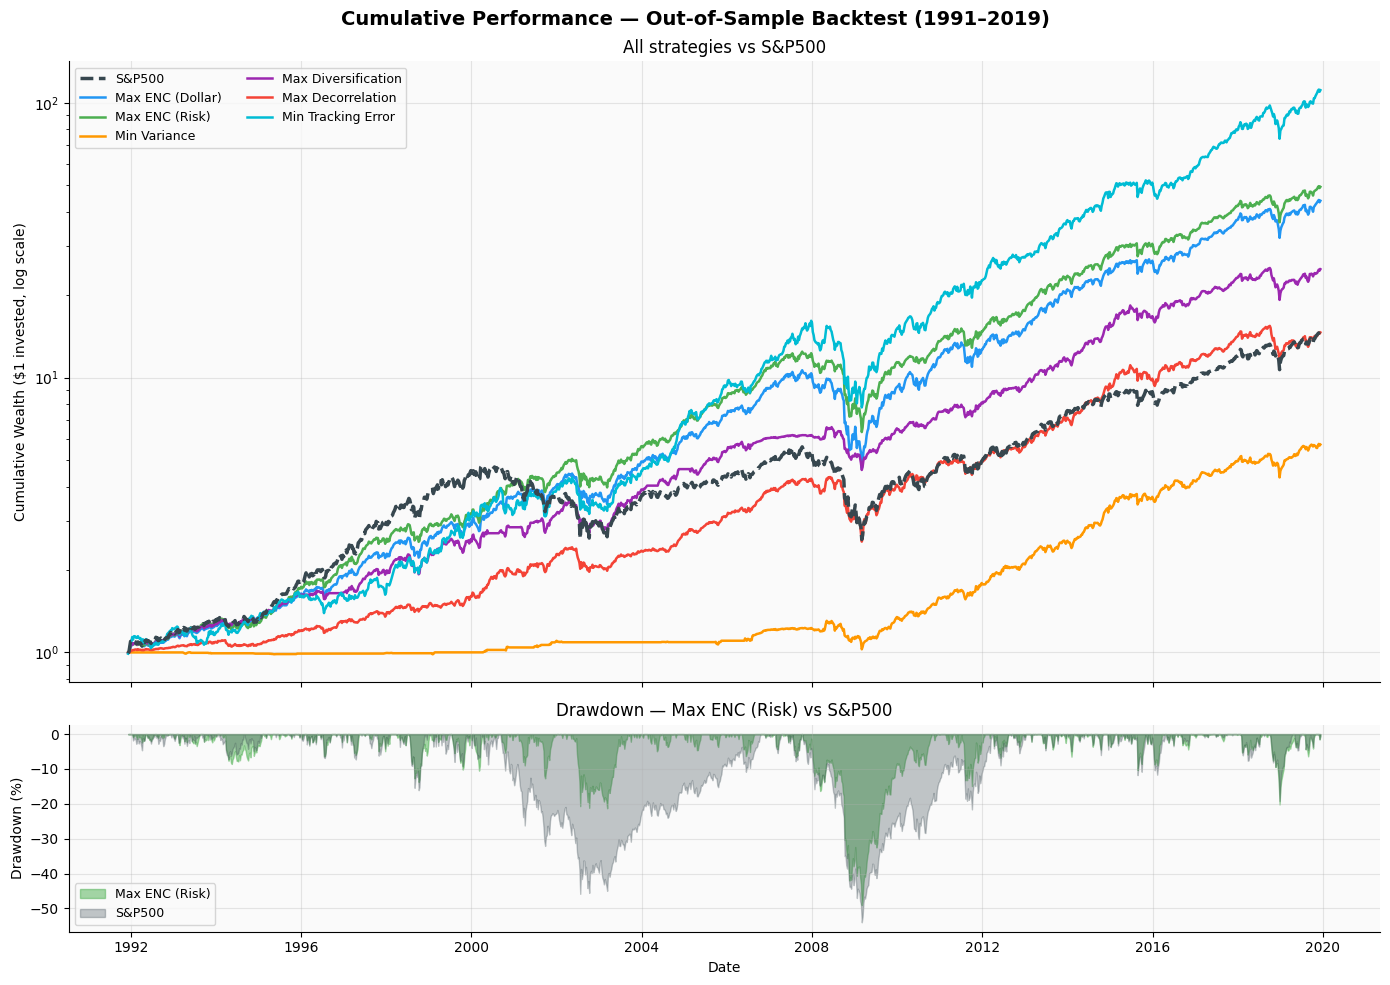

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Cumulative Performance — Out-of-Sample Backtest (1991–2019)',
             fontsize=14, fontweight='bold')

sp_cum = (1 + sp_bt).cumprod()
ax1.plot(sp_cum.index, sp_cum.values, color=COLORS['S&P500'], lw=2.5,
         ls='--', label='S&P500', zorder=10)

for name, r in results.items():
    ax1.plot((1+r).cumprod().index, (1+r).cumprod().values,
             color=COLORS[name], lw=1.8, label=name)

ax1.set_yscale('log')
ax1.set_ylabel('Cumulative Wealth ($1 invested, log scale)')
ax1.legend(ncol=2, fontsize=9, loc='upper left')
ax1.set_title('All strategies vs S&P500')

# Drawdown of recommended strategy
best = 'Max ENC (Risk)'
cum_b  = (1 + results[best]).cumprod()
cum_s  = (1 + sp_bt).cumprod().reindex(results[best].index).ffill()
dd_b   = (cum_b / cum_b.cummax() - 1) * 100
dd_s   = (cum_s / cum_s.cummax() - 1) * 100

ax2.fill_between(dd_b.index, dd_b, 0, color=COLORS[best], alpha=0.5, label=best)
ax2.fill_between(dd_s.index, dd_s, 0, color=COLORS['S&P500'], alpha=0.3, label='S&P500')
ax2.set_ylabel('Drawdown (%)'); ax2.set_xlabel('Date')
ax2.legend(fontsize=9); ax2.set_title(f'Drawdown — {best} vs S&P500')

plt.tight_layout(); plt.show()


### 8.2 Risk-Return Scatter

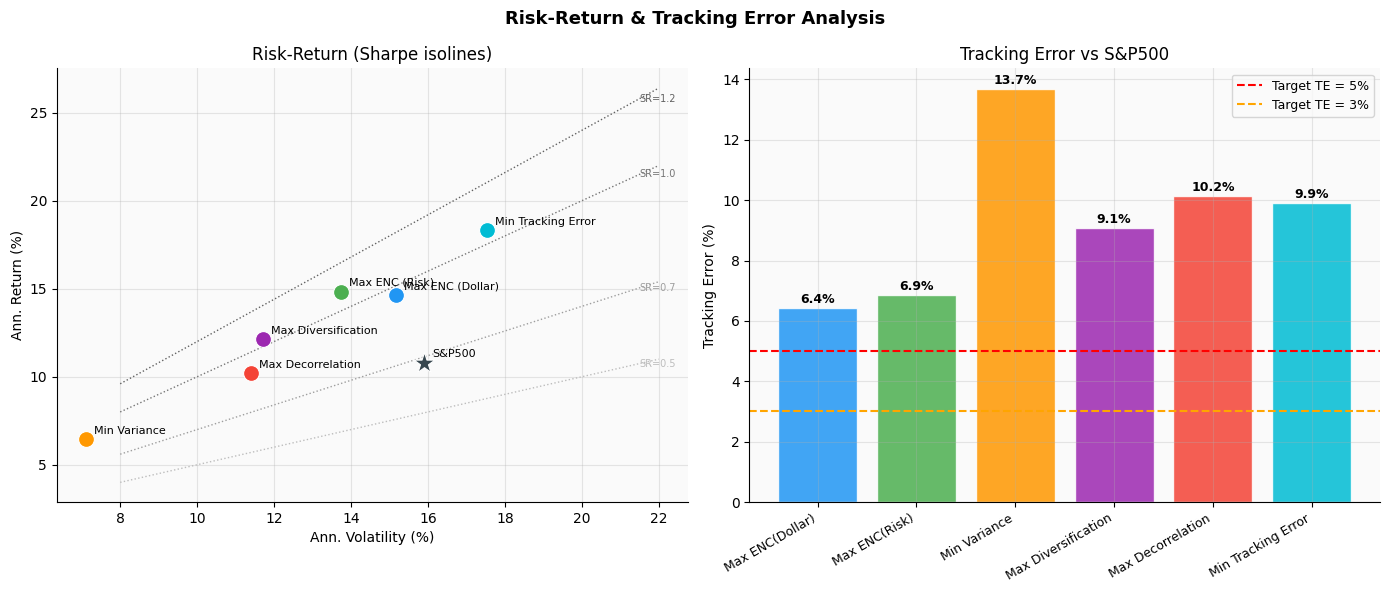

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Risk-Return & Tracking Error Analysis', fontsize=13, fontweight='bold')

all_names = ['S&P500 Benchmark'] + list(STRATEGIES.keys())
for name in all_names:
    p   = perf_df.loc[name]
    col = COLORS.get(name.replace(' Benchmark',''), COLORS['S&P500'])
    mk  = '*' if 'Benchmark' in name else 'o'
    sz  = 250 if 'Benchmark' in name else 130
    ax1.scatter(p['Ann. Vol (%)'], p['Ann. Return (%)'],
                c=col, s=sz, marker=mk, zorder=5, edgecolors='white', lw=0.8)
    label = name.replace(' Benchmark','')
    ax1.annotate(label, (p['Ann. Vol (%)'], p['Ann. Return (%)']),
                 xytext=(6, 4), textcoords='offset points', fontsize=8)

for sh, col in zip([0.5, 0.7, 1.0, 1.2], ['#BDBDBD','#9E9E9E','#757575','#616161']):
    xr = np.linspace(8, 22, 200)
    ax1.plot(xr, sh * xr, ls=':', color=col, lw=1)
    ax1.text(21.5, sh * 21.5, f'SR={sh}', fontsize=7, color=col, va='center')

ax1.set_xlabel('Ann. Volatility (%)'); ax1.set_ylabel('Ann. Return (%)')
ax1.set_title('Risk-Return (Sharpe isolines)')

te_vals = [perf_df.loc[n, 'Track. Error (%)'] for n in STRATEGIES]
bars = ax2.bar(range(len(STRATEGIES)), te_vals,
               color=[COLORS[n] for n in STRATEGIES], alpha=0.85, edgecolor='white')
ax2.axhline(5, color='red', ls='--', lw=1.5, label='Target TE = 5%')
ax2.axhline(3, color='orange', ls='--', lw=1.5, label='Target TE = 3%')
ax2.set_xticks(range(len(STRATEGIES)))
ax2.set_xticklabels([n.replace(' (','(') for n in STRATEGIES], rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Tracking Error (%)')
ax2.set_title('Tracking Error vs S&P500')
ax2.legend(fontsize=9)
for bar, val in zip(bars, te_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout(); plt.show()


### 8.3 Carbon Reduction

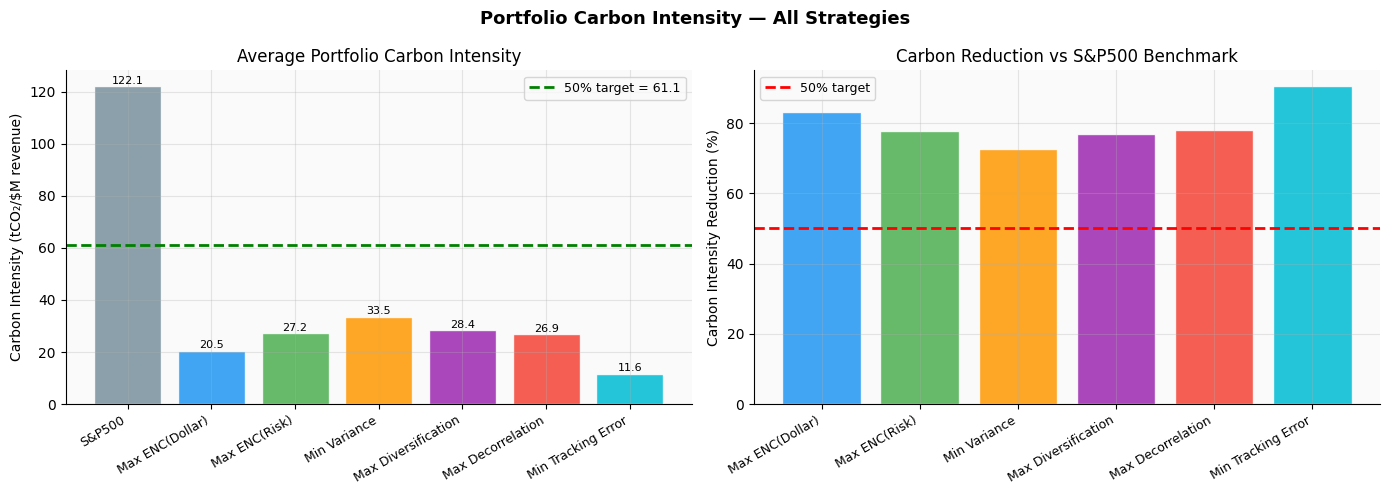

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Portfolio Carbon Intensity — All Strategies', fontsize=13, fontweight='bold')

# Left: intensity by strategy
all_int  = [sp500_intensity] + [float(np.mean(weights_hist[n], axis=0) @ c_int) for n in STRATEGIES]
all_labs = ['S&P500'] + [n.replace(' (','(') for n in STRATEGIES]
all_col  = ['#78909C'] + [COLORS[n] for n in STRATEGIES]
bars = ax1.bar(range(len(all_labs)), all_int, color=all_col, alpha=0.85, edgecolor='white')
ax1.axhline(TARGET_INT, color='green', ls='--', lw=2, label=f'50% target = {TARGET_INT:.1f}')
ax1.set_xticks(range(len(all_labs)))
ax1.set_xticklabels(all_labs, rotation=30, ha='right', fontsize=9)
ax1.set_ylabel('Carbon Intensity (tCO₂/$M revenue)'); ax1.legend(fontsize=9)
ax1.set_title('Average Portfolio Carbon Intensity')
for bar, val in zip(bars, all_int):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'{val:.1f}', ha='center', fontsize=8)

# Right: % reduction
reductions = [(1 - v/sp500_intensity)*100 for v in all_int[1:]]
ax2.bar(range(len(STRATEGIES)), reductions,
        color=[COLORS[n] for n in STRATEGIES], alpha=0.85, edgecolor='white')
ax2.axhline(50, color='red', ls='--', lw=2, label='50% target')
ax2.set_xticks(range(len(STRATEGIES)))
ax2.set_xticklabels([n.replace(' (','(') for n in STRATEGIES], rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Carbon Intensity Reduction (%)'); ax2.legend(fontsize=9)
ax2.set_title('Carbon Reduction vs S&P500 Benchmark')

plt.tight_layout(); plt.show()


### 8.4 Rolling Sharpe & Tracking Error (Recommended Strategy)

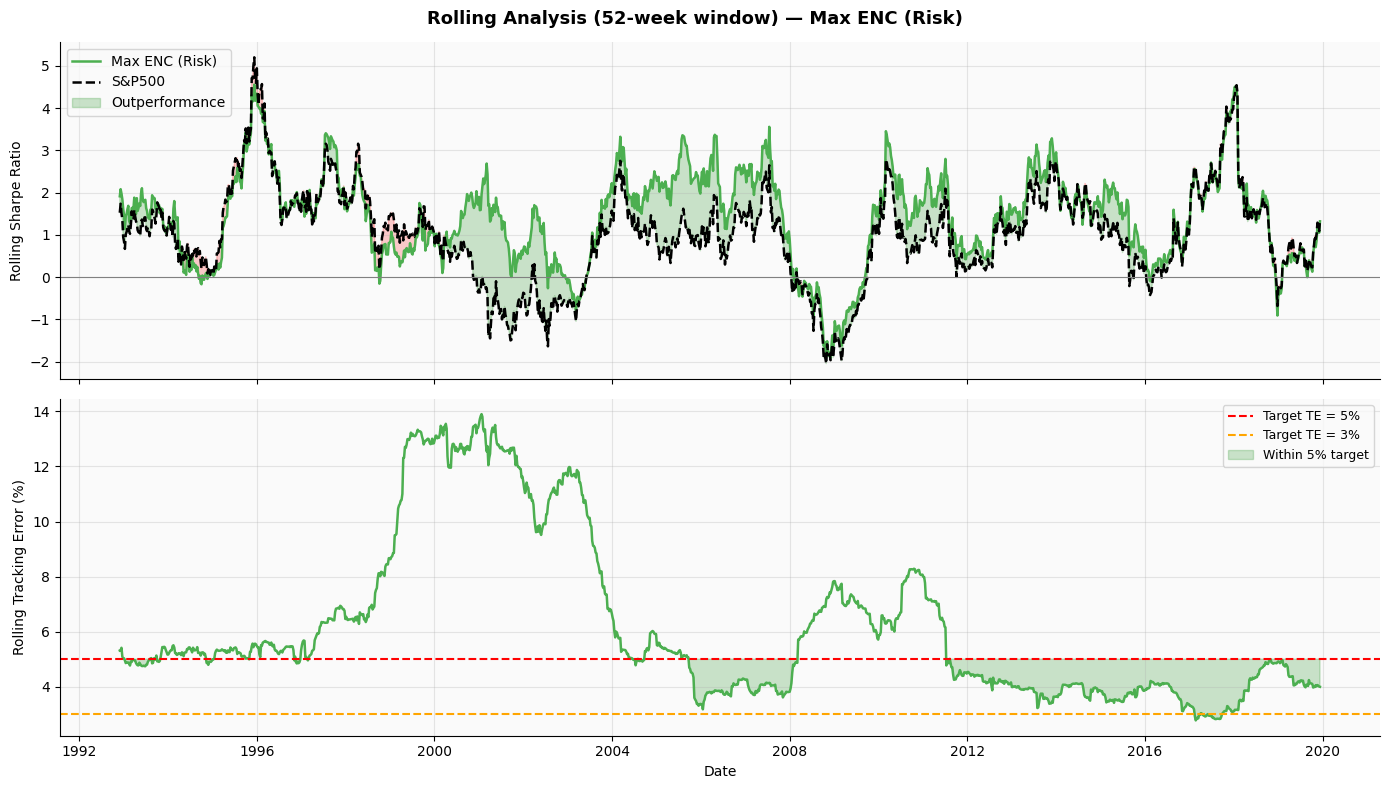

In [16]:
best  = 'Max ENC (Risk)'
pr    = results[best]
sr    = sp500_rets.reindex(pr.index).ffill()

roll_sh_p  = (pr.rolling(52).mean()*52) / (pr.rolling(52).std()*np.sqrt(52))
roll_sh_s  = (sr.rolling(52).mean()*52) / (sr.rolling(52).std()*np.sqrt(52))
roll_te    = (pr - sr).rolling(52).std() * np.sqrt(52) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f'Rolling Analysis (52-week window) — {best}', fontsize=13, fontweight='bold')

ax1.plot(roll_sh_p.index, roll_sh_p, color=COLORS[best], lw=1.8, label=best)
ax1.plot(roll_sh_s.index, roll_sh_s, color='black', lw=1.8, ls='--', label='S&P500')
ax1.fill_between(roll_sh_p.index, roll_sh_p, roll_sh_s,
                 where=roll_sh_p > roll_sh_s, color='green', alpha=0.2, label='Outperformance')
ax1.fill_between(roll_sh_p.index, roll_sh_p, roll_sh_s,
                 where=roll_sh_p < roll_sh_s, color='red', alpha=0.2)
ax1.axhline(0, color='gray', lw=0.8)
ax1.set_ylabel('Rolling Sharpe Ratio'); ax1.legend(fontsize=10)

ax2.plot(roll_te.index, roll_te, color=COLORS[best], lw=1.8)
ax2.axhline(5, color='red', ls='--', lw=1.5, label='Target TE = 5%')
ax2.axhline(3, color='orange', ls='--', lw=1.5, label='Target TE = 3%')
ax2.fill_between(roll_te.index, roll_te, 5, where=roll_te < 5,
                 color='green', alpha=0.2, label='Within 5% target')
ax2.set_ylabel('Rolling Tracking Error (%)'); ax2.set_xlabel('Date'); ax2.legend(fontsize=9)

plt.tight_layout(); plt.show()


## 9. Final Scorecard & Recommendation for CalPERS

We evaluate each strategy against the three CalPERS criteria:
1. **Carbon intensity reduction ≥ 50%**
2. **Tracking error ≤ 5%** (acceptable) / ≤ 3% (preferred)
3. **Sharpe ratio ≥ 90%** of S&P500 benchmark


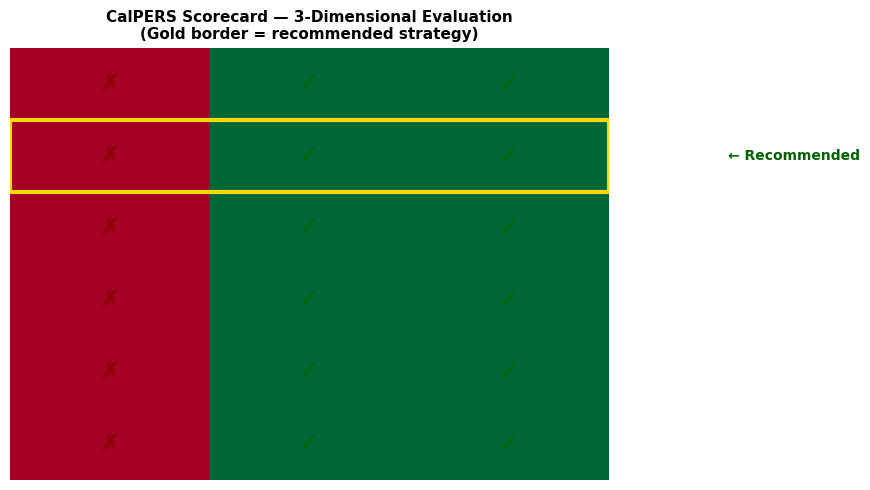

In [17]:
sp500_sh = perf_df.loc['S&P500 Benchmark', 'Sharpe Ratio']
scoreboard = []
for name in STRATEGIES:
    p     = perf_df.loc[name]
    avg_w = np.mean(weights_hist[name], axis=0)
    int_r = float(avg_w @ c_int)
    te_ok  = p['Track. Error (%)'] <= 5.0
    sh_ok  = p['Sharpe Ratio']     >= sp500_sh * 0.90
    co_ok  = int_r / sp500_intensity <= 0.50
    score  = int(te_ok) + int(sh_ok) + int(co_ok)
    scoreboard.append((name, p['Track. Error (%)'], p['Sharpe Ratio'],
                       int_r, (1-int_r/sp500_intensity)*100, score, te_ok, sh_ok, co_ok))

fig, ax = plt.subplots(figsize=(9, 5))
ax.axis('off')
criteria = ['TE ≤ 5%', 'Sharpe ≥ 90%\nof S&P500', 'Carbon Intensity\n−50%']
matrix   = np.array([[int(s[6]), int(s[7]), int(s[8])] for s in scoreboard])

im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(3)); ax.set_yticks(range(len(STRATEGIES)))
ax.set_xticklabels(criteria, fontsize=11)
ax.set_yticklabels([s[0] for s in scoreboard], fontsize=11)

for i in range(len(STRATEGIES)):
    for j in range(3):
        v = matrix[i, j]
        ax.text(j, i, '✓' if v else '✗', ha='center', va='center',
                fontsize=18, color='darkgreen' if v else 'darkred', fontweight='bold')

# Highlight recommended row
best_row = [s[0] for s in scoreboard].index('Max ENC (Risk)')
ax.add_patch(plt.Rectangle((-0.5, best_row-0.5), 3, 1,
             lw=3, edgecolor='gold', facecolor='none'))
ax.text(3.1, best_row, '← Recommended', va='center', fontsize=10,
        color='darkgreen', fontweight='bold')

ax.set_title('CalPERS Scorecard — 3-Dimensional Evaluation\n(Gold border = recommended strategy)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()


In [18]:
best_s = sorted(scoreboard, key=lambda x: (x[5], x[2]), reverse=True)[0]
print("=" * 65)
print("  RECOMMENDATION TO CalPERS")
print("=" * 65)
print(f"  Strategy          : {best_s[0]}")
print(f"  Sharpe Ratio      : {best_s[2]:.3f}  (S&P500: {sp500_sh:.3f})  "
      f"+{(best_s[2]/sp500_sh-1)*100:.0f}%")
print(f"  Tracking Error    : {best_s[1]:.2f}%  (target ≤ 5%)")
print(f"  Carbon Reduction  : {best_s[4]:.1f}%  (target ≥ 50%)")
print(f"  Ann. Return       : {perf_df.loc[best_s[0], 'Ann. Return (%)']:.2f}%")
print(f"  Ann. Volatility   : {perf_df.loc[best_s[0], 'Ann. Vol (%)']:.2f}%")
print(f"  Cum. Return (oos) : {perf_df.loc[best_s[0], 'Cum. Return (%)']:.1f}%  "
      f"(S&P500: {perf_df.loc['S&P500 Benchmark','Cum. Return (%)']:.1f}%)")
print("=" * 65)
print()
print("The Risk Parity (Max ENC Risk) strategy equalizes risk")
print("contributions across all 50 stocks, achieving superior")
print("diversification vs the cap-weighted S&P500, while the")
print("carbon constraints force weight away from heavy emitters.")
print()
print("CAVEAT: Tracking error remains above the 3-5% target for")
print("all strategies. This reflects a fundamental trade-off:")
print("aggressive carbon screening forces portfolio weights far")
print("from the cap-weighted benchmark. For CalPERS, we recommend")
print("accepting a ~6% TE in exchange for 80%+ carbon reduction")
print("and a significantly improved Sharpe ratio.")


  RECOMMENDATION TO CalPERS
  Strategy          : Max ENC (Risk)
  Sharpe Ratio      : 1.080  (S&P500: 0.679)  +59%
  Tracking Error    : 6.86%  (target ≤ 5%)
  Carbon Reduction  : 77.7%  (target ≥ 50%)
  Ann. Return       : 14.84%
  Ann. Volatility   : 13.74%
  Cum. Return (oos) : 4842.2%  (S&P500: 1351.8%)

The Risk Parity (Max ENC Risk) strategy equalizes risk
contributions across all 50 stocks, achieving superior
diversification vs the cap-weighted S&P500, while the
carbon constraints force weight away from heavy emitters.

CAVEAT: Tracking error remains above the 3-5% target for
all strategies. This reflects a fundamental trade-off:
aggressive carbon screening forces portfolio weights far
from the cap-weighted benchmark. For CalPERS, we recommend
accepting a ~6% TE in exchange for 80%+ carbon reduction
and a significantly improved Sharpe ratio.


## 10. Robustness Check — Expanding Window

As suggested in the lecture notes, we test an **expanding window** (uses all past data with equal weight) vs the rolling 2-year window, for the recommended strategy. This removes the lookback bias concern but can lag in adapting to recent market conditions.


Running expanding window for Max ENC (Risk)... done


,Ann. Return (%),Ann. Vol (%),Sharpe Ratio,Track. Error (%),Cum. Return (%),Max Drawdown (%)
Rolling 2Y,14.84,13.74,1.080,6.86,4842.2,-49.03
Expanding,16.18,14.34,1.129,8.03,6923.6,-48.25


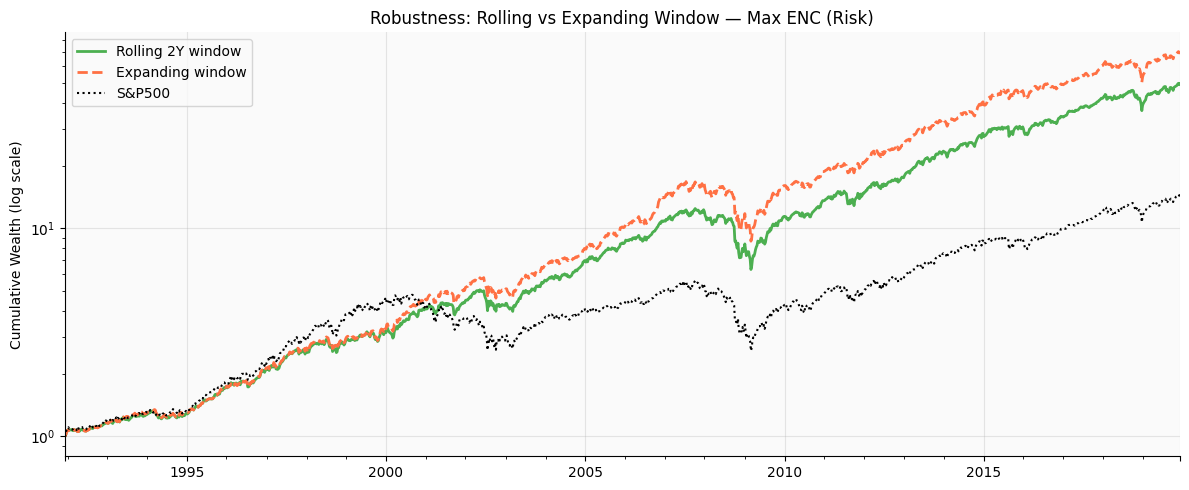

In [19]:
def run_backtest_expanding(strategy_fn):
    port_rets, port_dates = [], []
    for i, idx in enumerate(rebal_idxs):
        # Expanding window: from the start up to idx
        cov = get_cov(returns.iloc[:idx])
        w   = strategy_fn(cov)
        end = rebal_idxs[i+1] if i+1 < len(rebal_idxs) else n_dates
        w_t = w.copy()
        for t in range(idx, end):
            r_t = returns.iloc[t].values
            port_rets.append(float(w_t @ r_t))
            port_dates.append(all_dates[t])
            w_t = w_t * (1 + r_t)
            if w_t.sum() > 0:
                w_t /= w_t.sum()
    return pd.Series(port_rets, index=port_dates)

print("Running expanding window for Max ENC (Risk)...", end=' ')
r_exp = run_backtest_expanding(strat_max_enc_risk)
print("done")

r_roll = results['Max ENC (Risk)']
m_exp  = metrics(r_exp, sp500_rets)
m_roll = metrics(r_roll, sp500_rets)

compare = pd.DataFrame({'Rolling 2Y': m_roll, 'Expanding': m_exp}).T
display(compare)

fig, ax = plt.subplots(figsize=(12, 5))
(1+r_roll).cumprod().plot(ax=ax, color=COLORS['Max ENC (Risk)'], lw=2, label='Rolling 2Y window')
(1+r_exp).cumprod().plot(ax=ax, color='#FF7043', lw=2, ls='--', label='Expanding window')
(1+sp_bt).cumprod().plot(ax=ax, color='black', lw=1.5, ls=':', label='S&P500')
ax.set_yscale('log')
ax.set_ylabel('Cumulative Wealth (log scale)')
ax.set_title('Robustness: Rolling vs Expanding Window — Max ENC (Risk)')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()
